In [80]:
import cv2
import numpy as np
import random
from typing import Tuple, List
import matplotlib.pyplot as plt

#### Data preparation

##### Generating simple shapes on images

In [81]:
def random_color() -> Tuple[int, int, int]:
    return random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)


def sufficient_contrast(c1: Tuple, c2: Tuple,
                        threshold: int = 60) -> bool:  # checking if 2 colors are diff enough to be visible
    return sum(abs(int(a) - int(b)) for a, b in zip(c1, c2)) > threshold


def contrasting_color(background_color: Tuple,
                      threshold: int = 60) -> Tuple:  # generating a color that is diff enough with the bg colot
    for _ in range(100):
        color = random_color()
        if sufficient_contrast(color, background_color, threshold):
            return color
    return tuple((x + 128) % 256 for x in background_color)


In [82]:
def drawing_triangle(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    points = [(random.randint(10, width - 10), random.randint(10, height - 10)) for _ in range(3)]
    point_array = np.array(points, dtype=np.int32)
    color = contrasting_color(background_color)
    cv2.fillPoly(image, [point_array], color, lineType=cv2.LINE_AA)
    return points


def draw_quadrilateral(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    points = [(random.randint(10, width - 10), random.randint(10, height - 10)) for _ in range(4)]
    point_array = np.array(points, dtype=np.int32)
    color = contrasting_color(background_color)
    cv2.fillPoly(image, [point_array], color, lineType=cv2.LINE_AA)
    return points


def draw_star(image: np.ndarray, background_color: Tuple, min_dist: int = 15, max_dist: int = 35) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    color = contrasting_color(background_color)

    centered_x = random.randint(width // 4, 3 * width // 4)
    centered_y = random.randint(height // 4, 3 * height // 4)
    center = (centered_x, centered_y)

    outer = []
    attempts = 0
    while len(outer) < 5 and attempts < 200:
        # Pick points within a radius around center instead of anywhere in image
        angle = random.uniform(0, 2 * np.pi)
        dist = random.randint(min_dist, max_dist)
        px = int(np.clip(centered_x + dist * np.cos(angle), 10, width - 10))
        py = int(np.clip(centered_y + dist * np.sin(angle), 10, height - 10))

        if any(np.hypot(px - ox, py - oy) < min_dist for ox, oy in outer):
            attempts += 1
            continue
        outer.append((px, py))
        attempts += 1

    for pt in outer:
        cv2.line(image, center, pt, color, thickness=2, lineType=cv2.LINE_AA)

    return [center] + outer


def add_gauss_noise(image: np.ndarray, std: float = None) -> np.ndarray:
    if std is None:
        std = random.uniform(0.1, 0.3)
    noise = np.random.normal(0, std * 255, image.shape).astype(np.float32)
    noise = cv2.GaussianBlur(noise, (5, 5), 0)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

##### Generate complex shapes

In [83]:
def draw_chessboard(image: np.ndarray, background_color: Tuple, columns: int = 3, rows: int = 4) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]

    # Max cell size that guarantees the board fits with margins
    max_cell = (min(width, height) - 10) // max(columns, rows)
    if max_cell < 8:
        max_cell = 8
    cell_size = random.randint(8, max_cell)

    board_width = columns * cell_size
    board_height = rows * cell_size

    # Safe top-left origin
    max_ox = width - board_width - 5
    max_oy = height - board_height - 5

    if max_ox < 5 or max_oy < 5:
        # Board doesn't fit — shrink cell size to minimum
        cell_size = (min(width, height) - 10) // max(columns, rows)
        board_width = columns * cell_size
        board_height = rows * cell_size
        max_ox = max(5, width - board_width - 5)
        max_oy = max(5, height - board_height - 5)

    top_left_x = random.randint(5, max_ox)
    top_left_y = random.randint(5, max_oy)

    color1 = contrasting_color(background_color)
    color2 = contrasting_color(color1, 80)

    for row in range(rows):
        for column in range(columns):
            x1 = top_left_x + column * cell_size
            y1 = top_left_y + row * cell_size
            x2 = x1 + cell_size
            y2 = y1 + cell_size
            color = color1 if (row + column) % 2 == 0 else color2
            cv2.rectangle(image, (x1, y1), (x2, y2), color, -1)

    keypoints = []
    for row in range(rows + 1):
        for column in range(columns + 1):
            x = top_left_x + column * cell_size
            y = top_left_y + row * cell_size
            keypoints.append((x, y))

    return keypoints



def draw_3d_cube(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    color = contrasting_color(background_color)

    center_x = random.randint(width // 3, 2 * width // 3)
    center_y = random.randint(height // 3, 2 * height // 3)
    center = (center_x, center_y)

    min_dist = 20
    max_dist = min(width, height) // 4

    def random_offset_point(base_x, base_y):
        for _ in range(100):
            dx = random.randint(-max_dist, max_dist)
            dy = random.randint(-max_dist, max_dist)
            if abs(dx) > min_dist or abs(dy) > min_dist:
                px = np.clip(base_x + dx, 5, width - 5)
                py = np.clip(base_y + dy, 5, height - 5)
                return (int(px), int(py))
        return (base_x + min_dist, base_y + min_dist) ## todo can i write it in other way the whole function

    inner_point1 = random_offset_point(center_x, center_y)
    inner_point2 = random_offset_point(center_x, center_y)
    inner_point3 = random_offset_point(center_x, center_y)

    outer_point1 = random_offset_point(inner_point1[0], inner_point1[1])
    outer_point2 = random_offset_point(inner_point2[0], inner_point2[1])
    outer_point3 = random_offset_point(inner_point3[0], inner_point3[1])

    face_color_1 = contrasting_color(background_color, threshold=40)
    face_color_2 = contrasting_color(face_color_1, threshold=40)
    face_color_3 = contrasting_color(face_color_2, threshold=40)

    faces = [
        np.array([center, inner_point1, outer_point1, inner_point2], dtype=np.int32),
        np.array([center, inner_point2, outer_point2, inner_point3], dtype=np.int32),
        np.array([center, inner_point3, outer_point3, inner_point1], dtype=np.int32),
    ]

    for face, fc in zip(faces, [face_color_1, face_color_2, face_color_3]):
        cv2.fillPoly(image, [face], fc, lineType=cv2.LINE_AA)

    for face in faces:
        cv2.polylines(image, [face], isClosed=True, color=color, thickness=1, lineType=cv2.LINE_AA)

    keypoints = [center, inner_point1, inner_point2, inner_point3, outer_point1, outer_point2, outer_point3]
    return keypoints


In [84]:
# def generate_image(size: int = 128, shapes: List[str] = ['triangle', 'quadrilateral', 'star']) -> Tuple[
#     np.ndarray, List[Tuple[[int, int]]]]:
#     background_color = random_color()
#     image = np.ones((size, size, 3), dtype=np.uint8) * np.array(background_color, dtype=np.uint8)
#
#     all_keypoints = []
#
#     for shape in shapes:
#         if shape == 'triangle':
#             kps = draw_triangle(img, bg_color)
#         elif shape == 'quadrilateral':
#             kps = draw_quadrilateral(img, bg_color)
#         elif shape == 'star':
#             kps = draw_star(img, bg_color)
#         else:
#             raise ValueError(f"Unknown shape: {shape}")
#         all_keypoints.extend(kps)
#
#     return img, all_keypoints
def is_shape_overlapping(existing_mask: np.ndarray, new_mask: np.ndarray) -> bool:
    return np.any(existing_mask & new_mask)

def draw_shape(
    image: np.ndarray,
    background_color: Tuple,
    shape_type: str,
    existing_mask: np.ndarray,
    max_attempts: int = 20
) -> Tuple[List[Tuple[int, int]], bool]:
    height, width = image.shape[:2]

    for _ in range(max_attempts):
        temp_img = image.copy()
        temp_mask = np.zeros((height, width), dtype=np.uint8)

        if shape_type == 'triangle':
            kps = drawing_triangle(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            cv2.fillPoly(temp_mask, [pts], 1)

        elif shape_type == 'quadrilateral':
            kps = draw_quadrilateral(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            cv2.fillPoly(temp_mask, [pts], 1)

        elif shape_type == 'star':
            kps = draw_star(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillPoly(temp_mask, [hull], 1)

        elif shape_type == 'checkerboard':
            kps = draw_chessboard(temp_img, background_color)
            xs = [p[0] for p in kps]
            ys = [p[1] for p in kps]
            cv2.rectangle(temp_mask, (min(xs), min(ys)), (max(xs), max(ys)), 1, -1)

        elif shape_type == 'cube':
            kps = draw_3d_cube(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillPoly(temp_mask, [hull], 1)

        else:
            raise ValueError(f"Unknown shape: {shape_type}")

        if not is_shape_overlapping(existing_mask, temp_mask):
            image[:] = temp_img
            existing_mask |= temp_mask
            return kps, True

    return [], False

def generate_image(
    size: int = 128,
    shapes: List[str] = ['checkerboard', 'cube', 'quadrilateral', 'triangle', 'star']
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    assert size % 8 == 0, "Image size must be divisible by 8"

    background_color = random_color()
    image = np.ones((size, size, 3), dtype=np.uint8) * np.array(background_color, dtype=np.uint8)
    existing_mask = np.zeros((size, size), dtype=np.uint8)

    all_keypoints = []

    for shape in shapes:
        kps, success = draw_shape(image, background_color, shape, existing_mask, max_attempts=50)
        print(f"{shape}: success={success}, keypoints={len(kps)}")
        if success:
            all_keypoints.extend(kps)

    return image, all_keypoints

triangle: success=True, keypoints=3
quadrilateral: success=True, keypoints=4
star: success=True, keypoints=6
checkerboard: success=False, keypoints=0
cube: success=False, keypoints=0


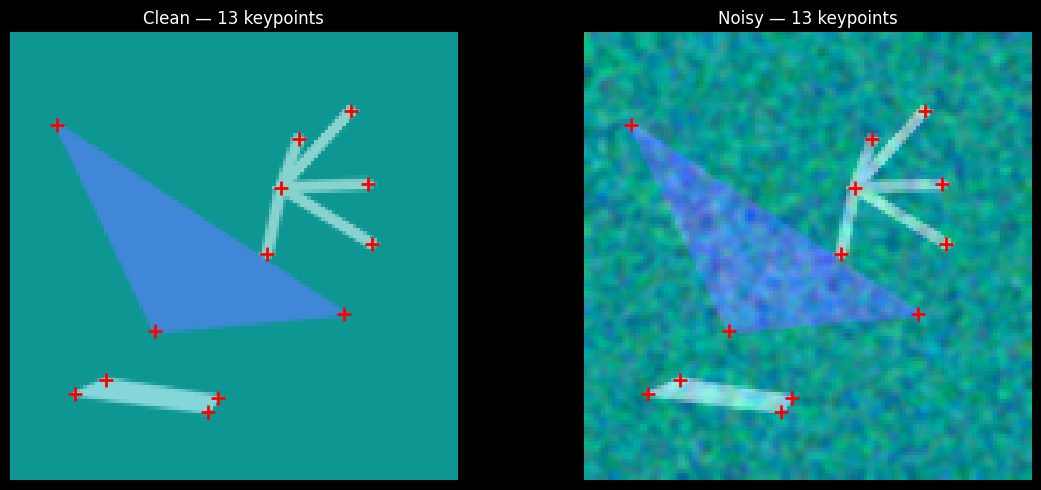

In [85]:
def visualize_sample(size: int = 128):
    shapes = ['triangle', 'quadrilateral', 'star', 'checkerboard', 'cube']
    img, keypoints = generate_image(size=size, shapes=shapes)
    img_noisy = add_gauss_noise(img)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for ax, image, title in zip(axs, [img, img_noisy], ['Clean', 'Noisy']):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        for (x, y) in keypoints:
            ax.plot(x, y, 'r+', markersize=10, markeredgewidth=2)
        ax.set_title(f'{title} — {len(keypoints)} keypoints')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_sample(128)